# Introduction

Given the initial prompt:
> Make a basic battleship game engine and an AI to play it.  Ideally, the AI would have some capability to learn, or some trained component.

the first thing that comes to mind is reinforcement learning because RL approaches have had a lot of success in game settings similar to this one. However, since machine learning is the [high-interest credit card of tech debt](https://static.googleusercontent.com/media/research.google.com/en//pubs/archive/43146.pdf) I also want to consider the maintenance burden associated with my approach. Reinforcement learning is more complex than standard supervised learning approaches and as a general rule I try to start with the simplest approach first and only add complexity as needed. Also I don't have experience with RL so learning it well enough to put something useful together in a couple hours seemed infeasible.

Given all that, I decided to approach the problem as a supervised learning problem. 

### Problem formulation

> Given a matrix $B$ representing the player's view of the opponent's board, train a function $G(B) \rightarrow P$ which generates a matrix $P$ containing the probability that there is a ship at each point in $B$.

Supervised models need training data, so the first step is to generate a set of labeled examples which show 
- observed shot results like a player observes in a game, and
- the probability that an opponent ship is at each point on the board given the observed shot results.

I used a sampling approach to generate these labels. The general idea was to first generate a reference set of many random board layouts. Then, to generate a sample training example:
1. Generate a random board layout and a random shot distribution
2. Calculate the results (hits and misses) of applying the shot distribution to the layout
3. Filter the reference set of board layouts to those which were compatible with the observed hits and misses
4. Sum over the filtered reference layouts to determine how often there was a ship at each board position.

The results of steps 2 and 4 above become a paired training example.

### Model definition and training

Once I had a set of training examples I defined a basic convolutional neural network model with a mean squared error loss function. I chose a convolutional model because they effectively capture spatial correlations which are present in this problem. Given more time I would continue to experiment with the model architecture (for example, by trying a conditional GAN approach) but in the interest of time I moved on to implementing the actual bot.

### Implementing the bot

Finally, I implemented a bot which matched the `battleship.game.Player` interface. This bot takes a pretrained model at instantiation. During play it then takes the observed state of the opponent's board, predicts ship locations using its pretrained model, and choses the square with the highest estimated probability of containg a ship.

## Potential next steps

Here are some things I would work on with more time.

### Code Improvements

#### Add type annotations, expand docstrings

I haven't used type annotations in the past, but since the provided code base does I'd add them to my code for consistency. I'd also include full docstrings for the public facing functions I added. In the past I've used numpy style docstrings.

#### Add unit tests

If this were going to be production code I'd also want to be sure it was covered by unit tests. In the past I've used the pytest framework.

#### Handle random seeds consistently

There are several places in the code where I use randomness. Debugging code with randomness is much easier when the random seeds are handled consistently. With more time I'd make this more robust using `np.random.RandomState` objects.

#### Improve the model training infrastructure

For this project I used Jupyter notebooks to iterate on the model. For bigger projects it would be helpful to set up some of the tensorflow model development tools (e.g. model checkpointing, Tensorboard, automated hyperparameter optimization).

#### Use a code autoformatter

My current team uses [black](https://github.com/psf/black) to autoformat our code and circumvent code formatting questions. The provided framework code used different conventions than I was used to (two space indents for example), so if the team were amenable I might advocate for adopting `black` as a way to standardize things.

### Bot Improvements

#### Improve the model

The performance of the model leaves so far isn't great. Intuitively this feels like a fairly tractable modeling problem, so with more time I'd explore different ways to make the model better at predicting ship locations. Some ideas that I didn't have time to explore:
- Use convolutional kernels shaped like the different ships
- Use a conditional GAN like Pix2Pix
- Use a loss function which upweights the known hits / misses


#### Improve the `choose_move` policy

Given a model to predict ship locations, we can choose a strategy which 
- chooses the square with the highest probability
- chooses the square which would reduce uncertainty the most
- does some combination of the two

The current policy always chooses the highest probability square. With more time it would be interesting to handle this explore / exploit tradeoff more intelligently (and modify the bot so that different policies could be easily swapped in and out).

#### Explore adversarial ship placement

The current approach assumes that the opponent ship distribution matches the random distribution we sampled from. If the opponent uses a different ship layout strategy that could affect the performance of this bot.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from battleship.board import empty_board
from battleship.game import ROWS, COLUMNS, SHIP_SIZES, play_one_game, ProbBot, RandomBot
from battleship.datagen import generate_training_data, generate_random_setup, generate_random_boards, generate_shots
from battleship.diagnostics import plot_shots, plot_shots_w_model
from battleship.model import build_model

# Generate the training data

In [3]:
# takes a minute or two on a ~2017 macbook pro
sample_boards = generate_random_boards(20000, ROWS, COLUMNS, SHIP_SIZES)

In [4]:
sample_boards.shape

(20000, 10, 10)

The "hits & misses" and "probs" arrays are what we'll pass into the network as X and y.

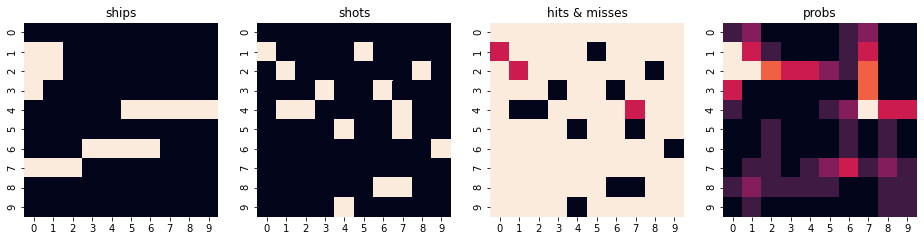

In [5]:
demo_board = generate_random_setup(SHIP_SIZES, empty_board(ROWS, COLUMNS))
demo_shots = generate_shots(15, demo_board)

plot_shots(demo_board, demo_shots, sample_boards)

In [6]:
Xs, ys = generate_training_data(
    n_train_samples=10000,
    sample_boards=sample_boards,
    rows=ROWS,
    columns=COLUMNS,
    ship_sizes=SHIP_SIZES)

In [7]:
Xs.shape

(10000, 10, 10, 1)

In [8]:
ys.shape

(10000, 10, 10, 1)

# Build and train the model

In [9]:
model = build_model(ROWS, COLUMNS, SHIP_SIZES)

In [10]:
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 10, 10, 1)]       0         
_________________________________________________________________
conv2d (Conv2D)              (None, 10, 10, 16)        416       
_________________________________________________________________
batch_normalization (BatchNo (None, 10, 10, 16)        64        
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 10, 10, 8)         1160      
_________________________________________________________________
batch_normalization_1 (Batch (None, 10, 10, 8)         32        
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 10, 10, 4)         292       
_________________________________________________________________
tf.math.reduce_mean (TFOpLam (None, 10, 10, 1)         0     

In [11]:
model.fit(x=Xs, y=ys, epochs=50, batch_size=512, validation_split=0.25)

Epoch 1/50
15/15 [==============================] - 3s 142ms/step - loss: 0.1131 - val_loss: 0.1156
Epoch 2/50
15/15 [==============================] - 1s 85ms/step - loss: 0.0968 - val_loss: 0.1303
Epoch 3/50
15/15 [==============================] - 1s 89ms/step - loss: 0.0884 - val_loss: 0.1582
Epoch 4/50
15/15 [==============================] - 1s 90ms/step - loss: 0.0806 - val_loss: 0.2243
Epoch 5/50
15/15 [==============================] - 1s 80ms/step - loss: 0.0748 - val_loss: 0.2814
Epoch 6/50
15/15 [==============================] - 1s 86ms/step - loss: 0.0719 - val_loss: 0.3178
Epoch 7/50
15/15 [==============================] - 1s 93ms/step - loss: 0.0713 - val_loss: 0.3354
Epoch 8/50
15/15 [==============================] - 1s 94ms/step - loss: 0.0698 - val_loss: 0.3527
Epoch 9/50
15/15 [==============================] - 1s 90ms/step - loss: 0.0694 - val_loss: 0.3553
Epoch 10/50
15/15 [==============================] - 1s 96ms/step - loss: 0.0690 - val_loss: 0.3510
Epoch 11

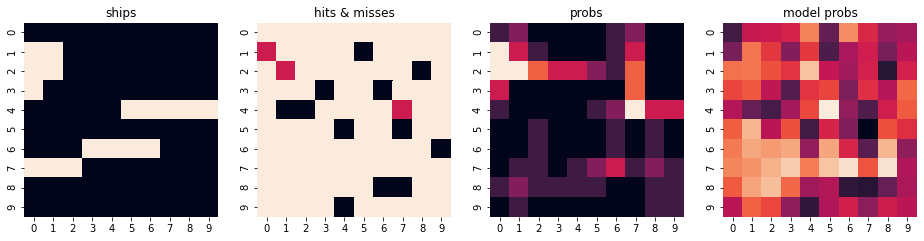

In [12]:
plot_shots_w_model(demo_board, demo_shots, model, sample_boards)

In [13]:
model.save('demo_model')

INFO:tensorflow:Assets written to: demo_model/assets


# Play some games

In [17]:
import numpy as np

from tqdm.notebook import tqdm

In [15]:
results = [play_one_game(ProbBot(model), RandomBot(), display=False) for _ in tqdm(range(100))]

🎉 Player 1 wins! 🎉
🏴‍☠️ Player 2 wins! 🏴‍☠️
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🏴‍☠️ Player 2 wins! 🏴‍☠️
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🏴‍☠️ Player 2 wins! 🏴‍☠️
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🏴‍☠️ Player 2 wins! 🏴‍☠️
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🏴‍☠️ Player 2 wins! 🏴‍☠️
🎉 Player 1 wins! 🎉
🏴‍☠️ Player 2 wins! 🏴‍☠️
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🏴‍☠️ Player 2 wins! 🏴‍☠️
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🏴‍☠️ Player 2 wins! 🏴‍☠️
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🏴‍☠️ Player 2 wins! 🏴‍☠️
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🏴‍☠️ Player 2 wins! 🏴‍☠️
🎉 Player 1 wins! 🎉
🎉 Player 1 wins! 🎉
🎉 Player 

In [18]:
winner, moves = zip(*results)

winner = np.array(winner)
moves = np.array(moves)

In [19]:
bot_wins = winner == 1

### Results

Looks like the probability model bot wins about 70-80% of the time against the random bot, and takes on average ~80 moves to win.

In [20]:
np.average(moves[bot_wins])

88.11111111111111

In [21]:
np.sum(bot_wins)

81